h = 0.06 | Total Accumulated Error = 0.317266
h = 0.11 | Total Accumulated Error = 0.398828
h = 0.16 | Total Accumulated Error = 0.349830
h = 0.21 | Total Accumulated Error = 0.363045
h = 0.26 | Total Accumulated Error = 0.340153
h = 0.31 | Total Accumulated Error = 0.411327
h = 0.36 | Total Accumulated Error = 0.401717
h = 0.41 | Total Accumulated Error = 0.343391
h = 0.46 | Total Accumulated Error = 0.475720
h = 0.51 | Total Accumulated Error = 0.364900
h = 0.56 | Total Accumulated Error = 0.452620
h = 0.61 | Total Accumulated Error = 0.527540
h = 0.66 | Total Accumulated Error = 0.665193
h = 0.71 | Total Accumulated Error = 0.711432
h = 0.76 | Total Accumulated Error = 0.905432
h = 0.81 | Total Accumulated Error = 1.119432
h = 0.86 | Total Accumulated Error = 1.353432
h = 0.91 | Total Accumulated Error = 1.607432
h = 0.96 | Total Accumulated Error = 1.881432


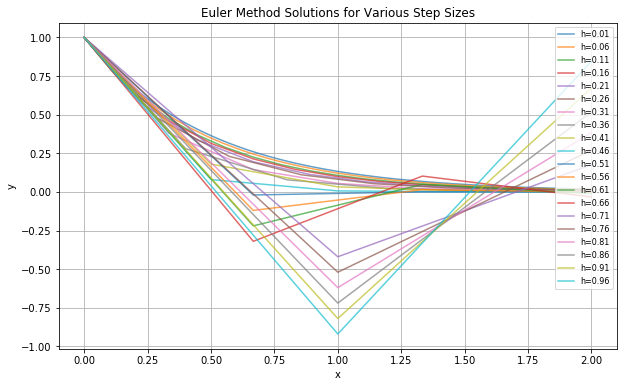

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Differential equation: dy/dx = -2y
def f(x, y):
    return -2 * y

# True solution for comparison (optional)
def y_true(x):
    return np.exp(-2*x)

# Step sizes from 0.01 to 1.0 in increments of 0.05
h_values = np.arange(0.01, 1.01, 0.05)

x_start, x_end = 0, 2

solutions = []   # store all y(x) curves
x_grids = []     # store x grids (different for each h)
errors_total = []  # accumulated error for each run

# -----------------------------
# Run Euler's method for each h
# -----------------------------
for idx, h in enumerate(h_values):

    num_steps = int((x_end - x_start) / h)
    x = np.linspace(x_start, x_end, num_steps + 1)
    y = np.zeros(num_steps + 1)

    # Initial condition
    y[0] = 1

    # Euler's method
    for i in range(num_steps):
        y[i + 1] = y[i] + h * f(x[i], y[i])

    solutions.append(y)
    x_grids.append(x)

    # Compute error vs first run (only after first run exists)
    if idx == 0:
        baseline_y = y  # store first run
        errors_total.append(0)  # baseline has no error
    else:
        # Interpolate baseline onto current x-grid
        baseline_interp = np.interp(x, x_grids[0], baseline_y)

        # Pointwise error
        point_errors = np.abs(y - baseline_interp)

        # Total accumulated error
        total_error = np.sum(point_errors)
        errors_total.append(total_error)

        print(f"h = {h:.2f} | Total Accumulated Error = {total_error:.6f}")

# -----------------------------
# Plot all Euler approximations
# -----------------------------
plt.figure(figsize=(10, 6))

for i, h in enumerate(h_values):
    plt.plot(x_grids[i], solutions[i], label=f"h={h:.2f}", alpha=0.7)

plt.title("Euler Method Solutions for Various Step Sizes")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="upper right", fontsize=8)
plt.grid(True)
plt.show()